# Regression Mini Project

In this notebook, I will build a complete machine learning regression workflow.

## Objectives

- Load and inspect a real dataset
- Seperate features and target
- Split data info training and test sets
- Create a baseline model
- Train a multiple linear regression model
- Generate predictions
- Evaluate the model using MAE, MSE, RMSE and R²
- Visualize predictions and residuals
- Interpret model coeffiecients


### Importing Libs

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split

### Creating Dataset

In [2]:
dataset = load_diabetes(as_frame=True)

df = dataset.frame.copy()

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
print(dataset.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### Inspecting Dataset

In [4]:
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())

df.info()

Shape:  (442, 11)
Columns:  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [5]:
df.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


### Inspecting missing and duplicated values

In [6]:
print("Missing Values: ")
print(df.isna().sum())

print("\nDuplicated Values: ")
print(df.duplicated().sum)

Missing Values: 
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Duplicated Values: 
<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
437    False
438    False
439    False
440    False
441    False
Length: 442, dtype: bool>


### Feature vs Target

In [7]:
X = df.drop(columns="target")
y = df["target"]

print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (442, 10)
y shape:  (442,)


### Train and Test 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

print("Training Samples: ", len(X_train))
print("Test Samples: ", len(X_test))

Training Samples:  353
Test Samples:  89


In [9]:
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

print("y_train Shape: ", y_train.shape)
print("y_test Shape: ", y_test.shape)

X_train Shape:  (353, 10)
X_test Shape:  (89, 10)
y_train Shape:  (353,)
y_test Shape:  (89,)


### Creating the Baseline Model

In [10]:
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

### Calculating Baseline Metrics

In [11]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions,
)

baseline_mse = mean_squared_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Basline MSE: {baseline_mse:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R² : {baseline_r2:.4f}")

Baseline MAE: 64.01
Basline MSE: 5361.53
Baseline RMSE: 73.22
Baseline R² : -0.0120


### Linear Regression Model

In [12]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 37.9 ,-241.96, 542.43,..., 275.32, 736.2 , 48.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [13]:
linear_predictions = linear_model.predict(X_test)

print("Prediction Count: ", len(linear_predictions))
print("First five predictions: ", linear_predictions[:5])

Prediction Count:  89
First five predictions:  [139.5475584  179.51720835 134.03875572 291.41702925 123.78965872]


### Calculating metrics of Linear Regression

In [14]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print(f"Linear Regression MAE: {linear_mae:.2f}")
print(f"Linear Regression MSE: {linear_mse:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression R²: {linear_r2:.2f}")

Linear Regression MAE: 42.79
Linear Regression MSE: 2900.19
Linear Regression RMSE: 53.85
Linear Regression R²: 0.45


In [15]:
#these are expected comparrisons

if (linear_mae < baseline_mae):
    print("MAE Done")
if (linear_rmse < baseline_rmse):
    print("RMSE Done")
if (linear_r2 > baseline_r2):
    print("R² Done")

MAE Done
RMSE Done
R² Done


### Result Table

In [16]:
metrics_df = pd.DataFrame(
    {
        "model": [
            "Mean Baseline",
            "Linear Regression"
        ],
        "mae": [
            baseline_mae,
            linear_mae
        ],
        "mse": [
            baseline_mse,
            linear_mse
        ],
        "rmse": [
            baseline_rmse,
            linear_rmse
        ],
        "r2": [
            baseline_r2,
            linear_r2
        ]
    }
)

metrics_df.round(3)

,model,mae,mse,rmse,r2
0,Mean Baseline,64.006,5361.533,73.222,-0.012
1,Linear Regression,42.794,2900.194,53.853,0.453


In [20]:
results_df = pd.DataFrame({
    "actual" : y_test.to_numpy(),
    "predicted" : linear_predictions
})

results_df["error"] = (
    results_df["actual"] - results_df["predicted"]
)

results_df["absolute_error"] = (
    results_df["error"].abs()
)

results_df.head(10).round(2)

,actual,predicted,error,absolute_error
0,219.0,139.55,79.45,79.45
1,70.0,179.52,-109.52,109.52
2,202.0,134.04,67.96,67.96
3,230.0,291.42,-61.42,61.42
4,111.0,123.79,-12.79,12.79
5,84.0,92.17,-8.17,8.17
6,242.0,258.23,-16.23,16.23
7,272.0,181.34,90.66,90.66
8,94.0,90.22,3.78,3.78
9,96.0,108.63,-12.63,12.63


In [21]:
worst_prediction = results_df.sort_values(
    by="absolute_error",
    ascending = False
)

worst_prediction.head(10).round(2)

,actual,predicted,error,absolute_error
61,52.0,206.49,-154.49,154.49
46,200.0,71.67,128.33,128.33
1,70.0,179.52,-109.52,109.52
27,77.0,180.39,-103.39,103.39
20,310.0,207.35,102.65,102.65
51,158.0,62.96,95.04,95.04
7,272.0,181.34,90.66,90.66
49,258.0,167.58,90.42,90.42
13,297.0,206.63,90.37,90.37
73,61.0,145.96,-84.96,84.96


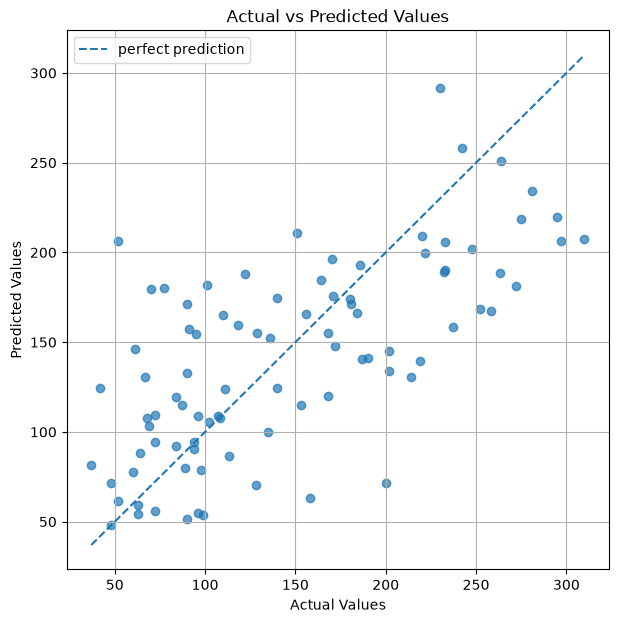

In [22]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    linear_predictions,
    alpha = 0.7
)

minimum_value = min(
    y_test.min(),
    linear_predictions.min()
)

maximum_value = max(
    y_test.max(),
    linear_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label = "perfect prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

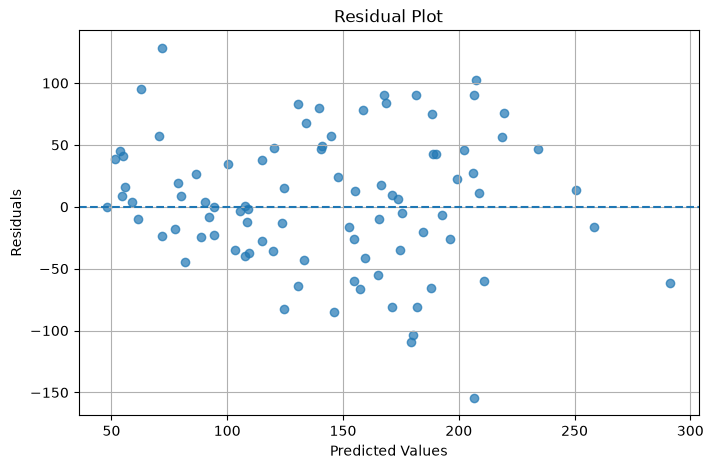

In [24]:
residuals = y_test.to_numpy() - linear_predictions

plt.figure(figsize=(8,5))

plt.scatter(
    linear_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle = "--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [26]:
coefficients_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": linear_model.coef_
})

coefficients_df["absolute_coefficient"] = (
    coefficients_df["coefficient"].abs()
)

coefficients_df = coefficients_df.sort_values(
    by = "absolute_coefficient",
    ascending= False
)

coefficients_df.round(2)

,feature,coefficient,absolute_coefficient
4,s1,-931.49,931.49
8,s5,736.20,736.20
2,bmi,542.43,542.43
5,s2,518.06,518.06
3,bp,347.70,347.70
7,s4,275.32,275.32
1,sex,-241.96,241.96
6,s3,163.42,163.42
9,s6,48.67,48.67
0,age,37.90,37.90


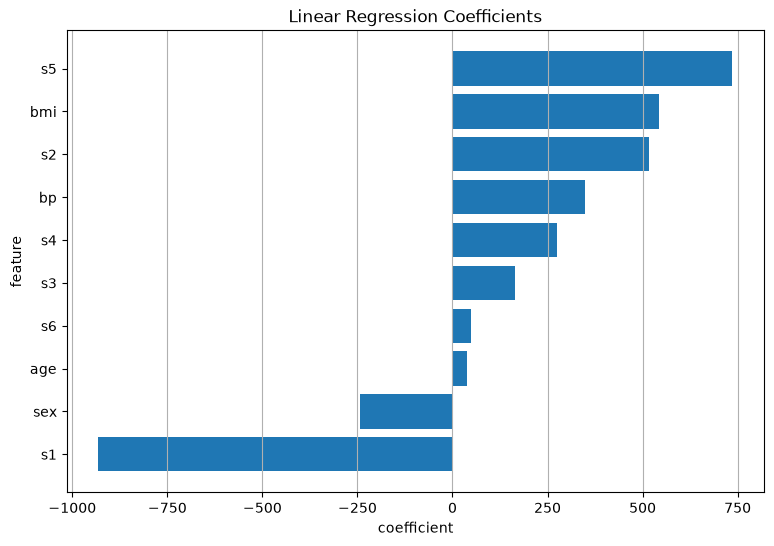

In [28]:
plot_df = coefficients_df.sort_values(
    by="coefficient"
)

plt.figure(figsize=(9,6))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.xlabel("coefficient")
plt.ylabel("feature")
plt.title("Linear Regression Coefficients")
plt.grid(axis="x")
plt.show()

In [29]:
sample = X_test.iloc[[0]]

sample_prediction = linear_model.predict(sample)

print("Input Features: ")
display(sample)

print("Actual Target: ", y_test.iloc[0])
print("Predicted Target: ", sample_prediction[0])

Input Features: 


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
287,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.00522


Actual Target:  219.0
Predicted Target:  139.54755840379607


## Conclusion

In this mini-project:

- I loaded and inspected a real regression dataset
- I seperated the feature matrix "x" and target vector "y"
- I split the data into training and test sets
- I created a mean baseline model.
- I trained a multiple linear regression model
- I evaluated both models using MAE, MSE, RMSE, and R2
- The linear regression model performed better than the baseline
- I compared actual and predicted values
- I examined residuals and model coefficients

The base line comparison is important because a machine learning model should perform better than a simple prediction strategy

This project used a random train/test split because the observations are not treated as a time series. In the stock prediction project, the data will be split chronologically.